# 카페 라벨링
- 다양한 방법으로, 각각 메모해서
- sales = Nan인 것 버리기

In [1]:
import pandas as pd
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df.isna().sum()
df.dropna(inplace=True)
# 매출 없는 것 43개 제외

# 중복 제거 (예: 상가업소번호 기준)
# df = df.drop_duplicates(subset='상가업소번호')
# df.to_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv', encoding = 'utf-8-sig', index = False)

## 방법1
- 모든 score 합산 (minmax 제외)
```
['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', 'minmax_review_score', '5bin_sales_score', '상권_코드']
```
- 성공 카페 기준 : 총합 일정 점수 이상

In [2]:
import pandas as pd
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df.dropna(inplace=True)
df = df[['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]
df['total_score'] = df['5bin_sales_score'] + df['5bin_review_score'] + df['rating_score'] +df['period_score']+ df['floor_score'] + df['parking_score']
# 만점은 22점
df_sucess = df[df['total_score'] >= 14]
len(df_sucess) # 9425개
df_sucess = df[df['total_score'] >= 15]
len(df_sucess) # 7685개
df_sucess = df[df['total_score'] >= 16]
len(df_sucess) # 5783개


5783

## 방법 2
- 모든 score 합산 (minmax 제외)
```
['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', 'minmax_review_score', '5bin_sales_score', '상권_코드']
```
- 성공 카페 기준 : 점수 상위 30% 만 성공으로 판단

In [3]:
import pandas as pd
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df.dropna(inplace=True)
df = df[['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]
df['total_score'] = df['5bin_sales_score'] + df['5bin_review_score'] + df['rating_score'] +df['period_score']+ df['floor_score'] + df['parking_score']
df['total_score'].describe()

count    18128.000000
mean        13.472858
std          4.299375
min          2.000000
25%         11.000000
50%         14.000000
75%         16.556250
max         22.000000
Name: total_score, dtype: float64

In [4]:
import pandas as pd
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df = df[['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]
df.dropna(inplace=True)
df['total_score'] = df['5bin_sales_score'] + df['5bin_review_score'] + df['rating_score'] +df['period_score']+ df['floor_score'] + df['parking_score']
df.sort_values(by = 'total_score', ascending = False, inplace=True)
percentage30 = round(len(df) * 0.3)
df_sucess = df[:percentage30]
# df_sucess.iloc[-1] # 상위 30% 의 total_score = 16.04

## 방법 3
- 모든 score 합산 (5bin_review_score 제외)
```
['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', 'minmax_review_score', '5bin_sales_score', '상권_코드']
```
- 성공 카페 기준 : 점수 상위 30% 만 성공으로 판단

In [5]:
import pandas as pd
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df = df[['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]
df['total_score'] = df['5bin_sales_score'] + df['5bin_review_score'] + df['rating_score'] +df['period_score']+ df['floor_score'] + df['parking_score']
df.describe()

,period_score,floor_score,parking_score,5bin_review_score,5bin_sales_score,rating_score,TRDAR_CD,total_score
count,18171.000000,18171.000000,18171.000000,18171.000000,18128.000000,18171.000000,1.817100e+04,18128.000000
mean,3.762864,0.867151,0.176875,2.556271,2.966075,3.143772,3.108649e+06,13.472858
std,1.694096,0.339421,0.381574,1.645481,1.385288,1.965116,1.518588e+05,4.299375
min,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-1.000000e+00,2.000000
25%,2.000000,1.000000,0.000000,1.000000,2.000000,0.000000,3.110595e+06,11.000000
50%,5.000000,1.000000,0.000000,3.000000,3.000000,4.150000,3.120041e+06,14.000000
75%,5.000000,1.000000,0.000000,4.000000,4.000000,4.620000,3.120164e+06,16.556250
max,5.000000,1.000000,1.000000,5.000000,5.000000,5.000000,3.130327e+06,22.000000


In [6]:
import pandas as pd
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df.dropna(inplace=True)
df = df[['상가업소번호', 'period_score', 'floor_score', 'parking_score', 'minmax_review_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]
df['total_score'] = df['5bin_sales_score'] + df['minmax_review_score'] + df['rating_score'] +df['period_score']+ df['floor_score'] + df['parking_score']
df.sort_values(by = 'total_score', ascending = False, inplace=True)
percentage30 = round(len(df) * 0.3)
df_sucess = df[:percentage30]
df_sucess.iloc[-1] # 상위 30% 의 total_score =  13.337972

상가업소번호                 MA0101202305A0104670
period_score                              4
floor_score                             0.0
parking_score                           0.0
minmax_review_score                0.912972
5bin_sales_score                        5.0
rating_score                          3.425
TRDAR_CD                            3110073
total_score                       13.337972
Name: 12494, dtype: object

## 방법 4
- reviews_score 제외하고 합산 (매출에 이미 반영되었음을 고려)
```
['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', 'minmax_review_score', '5bin_sales_score','rating_score', '상권_코드']
```
- 성공 카페 기준 : 2가지 모두

In [7]:
# - 성공 카페 기준 : 점수 상위 30% 만 성공으로 판단
import pandas as pd
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df.dropna(inplace = True)
df = df[['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]
df['total_score'] = df['5bin_sales_score'] + df['rating_score'] +df['period_score']+ df['floor_score'] + df['parking_score']
df.sort_values(by = 'total_score', ascending = False, inplace=True)
percentage30 = round(len(df) * 0.3)
df_sucess = df[:percentage30]
df_sucess.iloc[-1]  # 상위 30% 의 total_score =  13.2

상가업소번호              MA0101202212A0017466
period_score                           5
floor_score                          1.0
parking_score                        0.0
5bin_sales_score                     3.0
rating_score                         4.2
TRDAR_CD                         3120149
total_score                         13.2
Name: 11450, dtype: object

In [8]:
# - 성공 카페 기준 : 일정점수 이상
# 일정 점수의 기준은 다시 잡아야 할 수도 있음
import pandas as pd
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df.dropna(inplace = True)
df = df[['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]
df['total_score'] = df['5bin_sales_score'] + df['rating_score'] +df['period_score']+ df['floor_score'] + df['parking_score']
# 총점 달라짐 : 17
df_sucess = df[df['total_score'] >= 12]
print(len(df_sucess)) # 8112개
df_sucess = df[df['total_score'] >= 13]
print(len(df_sucess)) # 6003개
df_sucess = df[df['total_score'] >= 14]
print(len(df_sucess)) # 3817

8112
6003
3817


## 추가 방법
- 각 요소별로 가중치를 주는 방법 (논리적 근거 필요)

# 매물 추천 feature들과의 상관성 구하기
- 성공 카페 라벨링 후에, 수집한 feature와의 상관성 알아보기

## 방법1
- 모든 score 합산 (minmax 제외)
```
['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', 'minmax_review_score', '5bin_sales_score', '상권_코드']
```
- 성공 카페 기준 : 총합 일정 점수 이상

In [6]:
import pandas as pd
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df.dropna(inplace=True)
df = df[['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]

df['total_score'] = df['5bin_sales_score'] + df['5bin_review_score'] + df['rating_score'] +df['period_score']+ df['floor_score'] + df['parking_score']
# 만점은 22점
# df_sucess = df[df['total_score'] >= 14]
# len(df_sucess) # 9425개
# df_sucess = df[df['total_score'] >= 15]
# len(df_sucess) # 7685개

# 우선 16점 이상을 기준으로 라벨링하여 상관관계 보기
df['sucess'] = (df['total_score'] >= 16).astype(int)

features = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_통합_최종데이터.csv')
def convert_floor(floor):
    try:
        # B1, B2 등은 지하층을 의미하므로 음수로 변환
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        else:
            return int(floor)
    except:
        return None  # 오류가 나는 경우는 결측치로 처리
features['층정보'] = features['층정보'].apply(convert_floor)
features_with_label = pd.merge(features, df[['상가업소번호','sucess']], how = 'left', on = '상가업소번호')

cols = [
 '층정보',
 '경도',
 '위도',
 '지하철역_거리(m)',
 '버스정류장_거리(m)',
 '반경500m내_카페수',
 '총_유동인구_수',
 '피크_유동인구_수_상권별',
 '피크_유동인구_수_11~14',
 '평균_평일_유동인구_수',
 '평균_주말_유동인구_수',
 '평일_대비_주말_유동인구_비율',
 '전용면적',
 '리뷰수',
 '별점',
 '카페_추정매출',
 'sucess',
 'TRDAR_CD'
]

selected = features_with_label[cols].dropna()
correlation = selected.corr(numeric_only=True)['sucess'].sort_values(ascending=False)
print(correlation)


sucess              1.000000
리뷰수                 0.261550
별점                  0.173272
카페_추정매출             0.119284
평일_대비_주말_유동인구_비율    0.036566
지하철역_거리(m)          0.027709
총_유동인구_수            0.023793
피크_유동인구_수_11~14     0.013428
버스정류장_거리(m)         0.012172
피크_유동인구_수_상권별       0.007709
전용면적                0.001849
경도                 -0.000160
위도                 -0.004441
층정보                -0.014622
TRDAR_CD           -0.019643
평균_주말_유동인구_수       -0.021344
반경500m내_카페수        -0.028361
평균_평일_유동인구_수       -0.030804
Name: sucess, dtype: float64


In [8]:
import pandas as pd

# ------------------ 1. 점수 데이터 로드 및 라벨링 ------------------
df_score = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df_score.dropna(inplace=True)

# 필요한 컬럼만 선택
df_score = df_score[['상가업소번호', 'period_score', 'floor_score', 'parking_score',
                     '5bin_review_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]

# 총점 계산 및 성공 라벨링 (16점 이상 성공)
df_score['total_score'] = df_score['5bin_sales_score'] + df_score['5bin_review_score'] + df_score['rating_score'] + df_score['period_score'] + df_score['floor_score'] + df_score['parking_score']
df_score['sucess'] = (df_score['total_score'] >= 16).astype(int)

# ------------------ 2. 매물 feature 데이터 로드 ------------------
features = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_통합_최종데이터.csv')

# 층 정보 정리 함수
def convert_floor(floor):
    try:
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        else:
            return int(floor)
    except:
        return None

features['층정보'] = features['층정보'].apply(convert_floor)

# ------------------ 3. 유동인구 균등분배 데이터 로드 ------------------
p_feature = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\code\유동인구_균등분배.csv')

# '상가업소번호' 기준으로 유동인구 병합
features = pd.merge(features, p_feature[['상가업소번호', 'est_총_유동인구_수']], how='left', on='상가업소번호')

# ------------------ 4. 점수 라벨 병합 ------------------
features_with_label = pd.merge(features, df_score[['상가업소번호', 'sucess']], how='left', on='상가업소번호')

# ------------------ 5. 상관관계 분석 ------------------
cols = [
    '층정보',
    '경도',
    '위도',
    '지하철역_거리(m)',
    '버스정류장_거리(m)',
    '반경500m내_카페수',
    'est_총_유동인구_수',  # 균등분배된 유동인구 수
    '피크_유동인구_수_상권별',
    '피크_유동인구_수_11~14',
    '평균_평일_유동인구_수',
    '평균_주말_유동인구_수',
    '평일_대비_주말_유동인구_비율',
    '전용면적',
    '리뷰수',
    '별점',
    '카페_추정매출',
    'sucess',
    'TRDAR_CD'
]

# 결측치 제거 후 상관계수 계산
selected = features_with_label[cols].dropna()
correlation = selected.corr(numeric_only=True)['sucess'].sort_values(ascending=False)

# 결과 출력
print("성공 여부(sucess)와 각 feature 간의 상관관계:")
print(correlation)


성공 여부(sucess)와 각 feature 간의 상관관계:
sucess              1.000000
리뷰수                 0.261657
별점                  0.173095
카페_추정매출             0.119303
est_총_유동인구_수        0.043769
평일_대비_주말_유동인구_비율    0.036566
지하철역_거리(m)          0.027722
피크_유동인구_수_11~14     0.013392
버스정류장_거리(m)         0.012179
피크_유동인구_수_상권별       0.007671
전용면적                0.001837
경도                 -0.000116
위도                 -0.004562
층정보                -0.014598
TRDAR_CD           -0.019670
평균_주말_유동인구_수       -0.021413
반경500m내_카페수        -0.028439
평균_평일_유동인구_수       -0.030876
Name: sucess, dtype: float64


In [4]:
# 면적 기반 분배

import pandas as pd

# ------------------ 1. 점수 데이터 로드 및 라벨링 ------------------
df_score = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df_score.dropna(inplace=True)

# 필요한 컬럼만 선택
df_score = df_score[['상가업소번호', 'period_score', 'floor_score', 'parking_score',
                     '5bin_review_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]

# 총점 계산 및 성공 라벨링 (16점 이상 성공)
df_score['total_score'] = df_score['5bin_sales_score'] + df_score['5bin_review_score'] + df_score['rating_score'] + df_score['period_score'] + df_score['floor_score'] + df_score['parking_score']
df_score['sucess'] = (df_score['total_score'] >= 16).astype(int)

# ------------------ 2. 매물 feature 데이터 로드 ------------------
features = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_통합_최종데이터.csv')

# 층 정보 정리 함수
def convert_floor(floor):
    try:
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        else:
            return int(floor)
    except:
        return None

features['층정보'] = features['층정보'].apply(convert_floor)

# ------------------ 3. 유동인구 균등분배 데이터 로드 ------------------
p_feature = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\feature_population_0505.csv')
p_feature.rename(columns = {'피크_유동인구_수_상권별':'면적기반_피크_유동인구_상권별'}, inplace = True)

# '상가업소번호' 기준으로 유동인구 병합
features = pd.merge(features, p_feature[['상가업소번호', 'est_총_유동인구_수', 'est_시간대_11_14_유동인구_수','면적기반_피크_유동인구_상권별']], how='left', on='상가업소번호')

# ------------------ 4. 점수 라벨 병합 ------------------
features_with_label = pd.merge(features, df_score[['상가업소번호', 'sucess']], how='left', on='상가업소번호')

# ------------------ 5. 상관관계 분석 ------------------
cols = [
    '층정보',
    '경도',
    '위도',
    '지하철역_거리(m)',
    '버스정류장_거리(m)',
    '반경500m내_카페수',
    'est_총_유동인구_수',  # 균등분배된 유동인구 수
    '피크_유동인구_수_상권별',
    'est_시간대_11_14_유동인구_수',
    '면적기반_피크_유동인구_상권별',
    '평균_평일_유동인구_수',
    '평균_주말_유동인구_수',
    '평일_대비_주말_유동인구_비율',
    '전용면적',
    '리뷰수',
    '별점',
    '카페_추정매출',
    'sucess',
    'TRDAR_CD'
]

# 결측치 제거 후 상관계수 계산
selected = features_with_label[cols].dropna()
correlation = selected.corr(numeric_only=True)['sucess'].sort_values(ascending=False)

# 결과 출력
print("성공 여부(sucess)와 각 feature 간의 상관관계:")
print(correlation)


성공 여부(sucess)와 각 feature 간의 상관관계:
sucess                  1.000000
리뷰수                     0.255934
별점                      0.172059
카페_추정매출                 0.118582
est_총_유동인구_수            0.031684
피크_유동인구_수_상권별           0.028946
평일_대비_주말_유동인구_비율        0.020179
지하철역_거리(m)              0.019893
est_시간대_11_14_유동인구_수    0.019075
전용면적                    0.018431
면적기반_피크_유동인구_상권별        0.014122
버스정류장_거리(m)             0.007278
위도                      0.002379
경도                     -0.000354
층정보                    -0.009093
반경500m내_카페수            -0.020461
평균_주말_유동인구_수           -0.024630
TRDAR_CD               -0.025051
평균_평일_유동인구_수           -0.030675
Name: sucess, dtype: float64


['상가업소번호',
 '상호명',
 '지점명',
 'TRDAR_CD',
 'TRDAR_CD_N',
 '상권업종소분류코드',
 '상권업종소분류명',
 '시도코드',
 '시도명',
 '시군구코드',
 '시군구명',
 '행정동코드',
 '행정동명',
 '법정동코드',
 '법정동명',
 '지번코드',
 '대지구분코드',
 '대지구분명',
 '지번본번지',
 '지번부번지',
 '지번주소',
 '도로명코드',
 '도로명',
 '건물본번지',
 '건물부번지',
 '건물관리번호',
 '건물명',
 '도로명주소',
 '신우편번호',
 '동정보',
 '층정보',
 '호정보',
 '경도',
 '위도',
 '가장가까운_지하철역',
 '지하철역_거리(m)',
 '가장가까운_버스정류장',
 '버스정류장_거리(m)',
 '반경500m내_카페수',
 '밀집등급',
 '총_유동인구_수',
 '피크_유동인구_수_상권별',
 '기준_년분기_코드',
 '피크_유동인구_수_11~14',
 '상권_코드',
 '상권_코드_명',
 '평균_평일_유동인구_수',
 '평균_주말_유동인구_수',
 '평일_대비_주말_유동인구_비율',
 '전용면적',
 '리뷰수',
 '별점',
 '카페_추정매출',
 'sucess']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import font_manager, rc

# 한글 폰트 설정
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

cols = [
 '층정보',
 '경도',
 '위도',
 '지하철역_거리(m)',
 '버스정류장_거리(m)',
 '반경500m내_카페수',
 '총_유동인구_수',
 '피크_유동인구_수_상권별',
 '피크_유동인구_수_11~14',
 '평균_평일_유동인구_수',
 '평균_주말_유동인구_수',
 '평일_대비_주말_유동인구_비율',
 '전용면적'
]
# X, y 분리
X = selected[cols] # TRDAR_CD는 지역 구분용이라 제거
y = selected['sucess']

# 학습/검증 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 무한대 값을 NaN으로 변환
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)
# NaN 값 처리 (평균값으로 대체)
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())


# 모델 학습
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# 성능 확인
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# 중요도 시각화
importances = rf.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 10))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 방법 2
- 모든 score 합산 (minmax 제외)
```
['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', 'minmax_review_score', '5bin_sales_score', '상권_코드']
```
- 성공 카페 기준 : 점수 상위 30% 만 성공으로 판단

In [45]:
import pandas as pd
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df = df[['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]
df.dropna(inplace=True)
df['total_score'] = df['5bin_sales_score'] + df['5bin_review_score'] + df['rating_score'] +df['period_score']+ df['floor_score'] + df['parking_score']
df.sort_values(by = 'total_score', ascending = False, inplace=True)
percentage30 = round(len(df) * 0.3)
df_sucess = df[:percentage30]
# df_sucess.iloc[-1] # 상위 30% 의 total_score = 16.04
# 'sucess' 컬럼에 값 할당
df['sucess'] = 0
df.loc[:percentage30, 'sucess'] = 1  # loc 사용


features = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_통합_최종데이터.csv')
def convert_floor(floor):
    try:
        # B1, B2 등은 지하층을 의미하므로 음수로 변환
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        else:
            return int(floor)
    except:
        return None  # 오류가 나는 경우는 결측치로 처리
features['층정보'] = features['층정보'].apply(convert_floor)
features_with_label = pd.merge(features, df[['상가업소번호','sucess']], how = 'left', on = '상가업소번호')

cols = [
 '층정보',
 '경도',
 '위도',
 '지하철역_거리(m)',
 '버스정류장_거리(m)',
 '반경500m내_카페수',
 '총_유동인구_수',
 '피크_유동인구_수_상권별',
 '피크_유동인구_수_11~14',
 '평균_평일_유동인구_수',
 '평균_주말_유동인구_수',
 '평일_대비_주말_유동인구_비율',
 '전용면적',
 '리뷰수',
 '별점',
 '카페_추정매출',
 'sucess',
 'TRDAR_CD'
]

selected = features_with_label[cols].dropna()
correlation = selected.corr(numeric_only=True)['sucess'].sort_values(ascending=False)
print(correlation)


sucess              1.000000
별점                  0.204666
리뷰수                 0.158271
카페_추정매출             0.084374
전용면적                0.036046
버스정류장_거리(m)         0.021373
총_유동인구_수            0.017737
지하철역_거리(m)          0.015617
피크_유동인구_수_11~14     0.013059
평일_대비_주말_유동인구_비율    0.012701
경도                  0.007292
위도                  0.007279
피크_유동인구_수_상권별       0.006559
TRDAR_CD           -0.001841
평균_주말_유동인구_수       -0.022302
반경500m내_카페수        -0.024341
층정보                -0.024557
평균_평일_유동인구_수       -0.026882
Name: sucess, dtype: float64


              precision    recall  f1-score   support

         0.0       0.26      0.51      0.34       506
         1.0       0.76      0.51      0.61      1537

    accuracy                           0.51      2043
   macro avg       0.51      0.51      0.48      2043
weighted avg       0.64      0.51      0.54      2043



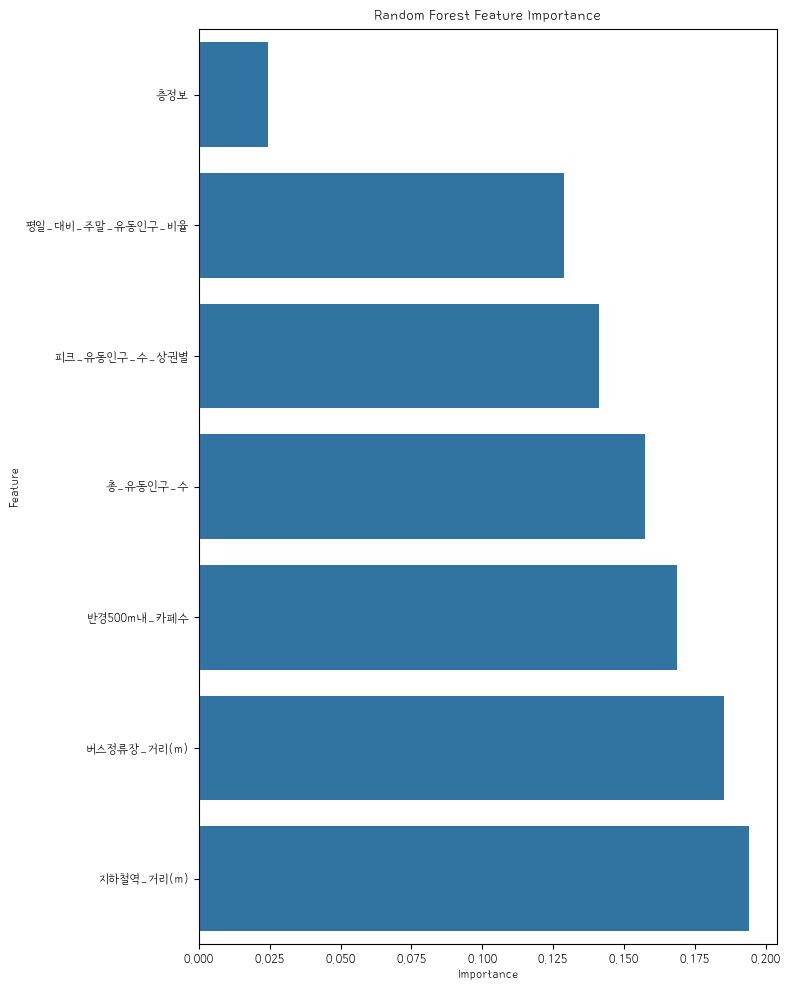

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import font_manager, rc
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# 한글 폰트 설정
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

cols = [
    '층정보',
    # '경도',
    # '위도',
    '지하철역_거리(m)',
    '버스정류장_거리(m)',
    '반경500m내_카페수',
    '총_유동인구_수',
    '피크_유동인구_수_상권별',
    # '피크_유동인구_수_11~14',
    # '평균_평일_유동인구_수',
    # '평균_주말_유동인구_수',
    '평일_대비_주말_유동인구_비율',
    # '전용면적'
]
# X, y 분리
X = selected[cols] # TRDAR_CD는 지역 구분용이라 제거
y = selected['sucess']

# 학습/검증 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 무한대 값을 NaN으로 변환
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)
# NaN 값 처리 (평균값으로 대체)
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

# 클래스 불균형 처리 (언더샘플링)
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

# 모델 학습 (재샘플링된 데이터로 학습)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_resampled, y_resampled)

# 예측 및 성능 확인
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# 중요도 시각화
importances = rf.feature_importances_
feature_names = cols  # 수정
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 10))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 방법 3
- 모든 score 합산 (5bin_review_score 제외)
```
['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', 'minmax_review_score', '5bin_sales_score', '상권_코드']
```
- 성공 카페 기준 : 점수 상위 30% 만 성공으로 판단

In [11]:
import pandas as pd
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df.dropna(inplace=True)
df = df[['상가업소번호', 'period_score', 'floor_score', 'parking_score', 'minmax_review_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]
df['total_score'] = df['5bin_sales_score'] + df['minmax_review_score'] + df['rating_score'] +df['period_score']+ df['floor_score'] + df['parking_score']
df.sort_values(by = 'total_score', ascending = False, inplace=True)
percentage30 = round(len(df) * 0.3)
df_sucess = df[:percentage30]
df_sucess.iloc[-1] # 상위 30% 의 total_score =  13.337972

df['sucess'] = 0
df.loc[:percentage30, 'sucess'] = 1  # loc 사용
features = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_통합_최종데이터.csv')
features_with_label = pd.merge(features, df[['상가업소번호','sucess']], how = 'left', on = '상가업소번호')

cols = [
 '층정보',
 '경도',
 '위도',
 '지하철역_거리(m)',
 '버스정류장_거리(m)',
 '반경500m내_카페수',
 '총_유동인구_수',
 '피크_유동인구_수_상권별',
 '피크_유동인구_수_11~14',
 '평균_평일_유동인구_수',
 '평균_주말_유동인구_수',
 '평일_대비_주말_유동인구_비율',
 '전용면적',
 '리뷰수',
 '별점',
 '카페_추정매출',
 'sucess',
 'TRDAR_CD'
]

selected = features_with_label[cols].dropna()
correlation = selected.corr(numeric_only=True)['sucess'].sort_values(ascending=False)
print(correlation)


sucess              1.000000
리뷰수                 0.210950
별점                  0.173771
카페_추정매출             0.086948
평일_대비_주말_유동인구_비율    0.042507
지하철역_거리(m)          0.032914
총_유동인구_수            0.030191
피크_유동인구_수_11~14     0.020697
버스정류장_거리(m)         0.018206
전용면적                0.016920
피크_유동인구_수_상권별       0.014020
위도                  0.012742
경도                  0.005529
TRDAR_CD           -0.022949
평균_주말_유동인구_수       -0.029082
반경500m내_카페수        -0.037255
평균_평일_유동인구_수       -0.040271
Name: sucess, dtype: float64


## 방법 4
- reviews_score 제외하고 합산 (매출에 이미 반영되었음을 고려)
```
['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_review_score', 'minmax_review_score', '5bin_sales_score','rating_score', '상권_코드']
```
- 성공 카페 기준 : 둘 다

In [12]:
# - 성공 카페 기준 : 점수 상위 30% 만 성공으로 판단
import pandas as pd
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df.dropna(inplace = True)
df = df[['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]
df['total_score'] = df['5bin_sales_score'] + df['rating_score'] +df['period_score']+ df['floor_score'] + df['parking_score']
df.sort_values(by = 'total_score', ascending = False, inplace=True)
percentage30 = round(len(df) * 0.3)
df_sucess = df[:percentage30]
df_sucess.iloc[-1]  # 상위 30% 의 total_score =  13.2

df['sucess'] = 0
df.loc[:percentage30, 'sucess'] = 1  # loc 사용
features = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_통합_최종데이터.csv')
features_with_label = pd.merge(features, df[['상가업소번호','sucess']], how = 'left', on = '상가업소번호')

cols = [
 '층정보',
 '경도',
 '위도',
 '지하철역_거리(m)',
 '버스정류장_거리(m)',
 '반경500m내_카페수',
 '총_유동인구_수',
 '피크_유동인구_수_상권별',
 '피크_유동인구_수_11~14',
 '평균_평일_유동인구_수',
 '평균_주말_유동인구_수',
 '평일_대비_주말_유동인구_비율',
 '전용면적',
 '리뷰수',
 '별점',
 '카페_추정매출',
 'sucess',
 'TRDAR_CD'
]

selected = features_with_label[cols].dropna()
correlation = selected.corr(numeric_only=True)['sucess'].sort_values(ascending=False)
print(correlation)


sucess              1.000000
리뷰수                 0.196020
별점                  0.173750
카페_추정매출             0.085035
평일_대비_주말_유동인구_비율    0.033263
지하철역_거리(m)          0.022623
전용면적                0.021900
총_유동인구_수            0.020457
버스정류장_거리(m)         0.016260
피크_유동인구_수_11~14     0.015232
피크_유동인구_수_상권별       0.009045
위도                  0.008245
경도                  0.002267
평균_주말_유동인구_수       -0.017381
TRDAR_CD           -0.020639
반경500m내_카페수        -0.023471
평균_평일_유동인구_수       -0.026751
Name: sucess, dtype: float64


In [13]:
# - 성공 카페 기준 : 일정점수 이상
# 일정 점수의 기준은 다시 잡아야 할 수도 있음
import pandas as pd
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_점수_0503.csv')
df.dropna(inplace = True)
df = df[['상가업소번호', 'period_score', 'floor_score', 'parking_score', '5bin_sales_score', 'rating_score','TRDAR_CD']]
df['total_score'] = df['5bin_sales_score'] + df['rating_score'] +df['period_score']+ df['floor_score'] + df['parking_score']
# 총점 달라짐 : 17
df_sucess = df[df['total_score'] >= 12]
# print(len(df_sucess)) # 8112개
df_sucess = df[df['total_score'] >= 13]
# print(len(df_sucess)) # 6003개
df_sucess = df[df['total_score'] >= 14]
# print(len(df_sucess)) # 3817

# 우선 16점 이상을 기준으로 라벨링하여 상관관계 보기
df['sucess'] = (df['total_score'] >= 14).astype(int)

features = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_통합_최종데이터.csv')
features_with_label = pd.merge(features, df[['상가업소번호','sucess']], how = 'left', on = '상가업소번호')

cols =[
 '층정보',
 '경도',
 '위도',
 '지하철역_거리(m)',
 '버스정류장_거리(m)',
 '반경500m내_카페수',
 '총_유동인구_수',
 '피크_유동인구_수_상권별',
 '피크_유동인구_수_11~14',
 '평균_평일_유동인구_수',
 '평균_주말_유동인구_수',
 '평일_대비_주말_유동인구_비율',
 '전용면적',
 '리뷰수',
 '별점',
 '카페_추정매출',
 'sucess',
 'TRDAR_CD'
]

selected = features_with_label[cols].dropna()
correlation = selected.corr(numeric_only=True)['sucess'].sort_values(ascending=False)
print(correlation)


sucess              1.000000
리뷰수                 0.228533
별점                  0.181672
카페_추정매출             0.097366
버스정류장_거리(m)         0.025256
평일_대비_주말_유동인구_비율    0.022712
지하철역_거리(m)          0.020571
총_유동인구_수            0.018321
피크_유동인구_수_11~14     0.011489
경도                  0.009849
전용면적                0.009359
피크_유동인구_수_상권별       0.004879
위도                  0.002237
평균_주말_유동인구_수       -0.006778
평균_평일_유동인구_수       -0.013583
반경500m내_카페수        -0.016193
TRDAR_CD           -0.032049
Name: sucess, dtype: float64
